In [1]:
# download midis_v1.2.zip from https://drive.google.com/drive/folders/1Stz3CAvMoplo79LR5I3onMWRelCugBYS
# put the midis folder into data/raw

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from preprocessing import preprocess_dataset, load_pickle
from markov import (
    train_event_unigram,
    train_event_bigram,
    train_event_second_order,
    generate_event_unigram,
    generate_event_bigram,
    generate_event_second_order
)
from midi_output import save_event_midi

random.seed(0)
np.random.seed(0)

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "midis"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw dir:", RAW_DIR)
print("Raw dir exists:", RAW_DIR.exists())
print("Processed dir:", PROCESSED_DIR)
print("Output dir:", OUTPUT_DIR)

Project root: c:\CSE153-Assignment-2-Task-1
Raw dir: c:\CSE153-Assignment-2-Task-1\data\raw\midis
Raw dir exists: True
Processed dir: c:\CSE153-Assignment-2-Task-1\data\processed
Output dir: c:\CSE153-Assignment-2-Task-1\outputs


In [3]:
# ONLY NEED TO RUN ONCE PER SESSION

train_songs, test_songs, failed = preprocess_dataset(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    max_files=500,
    min_events=20,
    max_chord_size=8,
    test_size=0.2,
    seed=0
)

MIDI files found: 10841
Processed 100/500 files | usable: 100 | failed: 0
Processed 200/500 files | usable: 200 | failed: 0
Processed 300/500 files | usable: 299 | failed: 0
Processed 400/500 files | usable: 399 | failed: 0
Processed 500/500 files | usable: 499 | failed: 0
Usable songs: 499
Train songs: 399
Test songs: 100
Failed files: 0


In [4]:
train_songs = load_pickle(PROCESSED_DIR / "train_songs.pkl")
test_songs = load_pickle(PROCESSED_DIR / "test_songs.pkl")
failed = load_pickle(PROCESSED_DIR / "failed_files.pkl")

print("Train songs:", len(train_songs))
print("Test songs:", len(test_songs))
print("Failed files:", len(failed))

Train songs: 399
Test songs: 100
Failed files: 0


In [5]:
example = train_songs[0]

print("Example path:", example["path"])
print("Number of events:", example["num_events"])
print("Number of notes:", example["num_notes"])
print("First 5 events:")

for event in example["events"][:5]:
    print(event)

Example path: c:\CSE153-Assignment-2-Task-1\data\raw\midis\Ascher, Joseph, La perle du nord, hdAV8nPxnw4.mid
Number of events: 1153
Number of notes: 3091
First 5 events:
{'gap': 0, 'pitches': (55, 58, 63, 67, 70, 75), 'durations': (120, 120, 120, 120, 120, 120), 'velocities': (96, 102, 97, 90, 97, 91)}
{'gap': 120, 'pitches': (55, 58, 63, 67, 70, 75), 'durations': (1200, 1920, 1200, 1200, 1200, 1200), 'velocities': (83, 97, 86, 83, 104, 97)}
{'gap': 1200, 'pitches': (55, 59, 59, 63, 63, 67, 71, 71), 'durations': (720, 120, 720, 120, 600, 840, 120, 720), 'velocities': (97, 101, 99, 97, 81, 89, 95, 101)}
{'gap': 600, 'pitches': (56, 60, 63, 68, 72), 'durations': (120, 120, 120, 120, 120), 'velocities': (101, 104, 94, 106, 95)}
{'gap': 120, 'pitches': (56, 60, 63, 68, 72), 'durations': (120, 120, 120, 120, 480), 'velocities': (98, 100, 84, 107, 102)}


In [6]:
all_events = [
    event
    for song in train_songs
    for event in song["events"]
]

all_pitches = [
    pitch
    for event in all_events
    for pitch in event["pitches"]
]

all_durations = [
    duration
    for event in all_events
    for duration in event["durations"]
]

all_gaps = [
    event["gap"]
    for event in all_events
]

song_event_lengths = [
    song["num_events"]
    for song in train_songs
]

chord_sizes = [
    len(event["pitches"])
    for event in all_events
]

event_intervals = []

for song in train_songs:
    melody_like_pitches = [
        max(event["pitches"])
        for event in song["events"]
        if len(event["pitches"]) > 0
    ]

    event_intervals.extend([
        b - a
        for a, b in zip(melody_like_pitches[:-1], melody_like_pitches[1:])
    ])

summary = pd.DataFrame({
    "num_train_songs": [len(train_songs)],
    "num_test_songs": [len(test_songs)],
    "num_train_events": [len(all_events)],
    "num_train_notes": [len(all_pitches)],
    "min_pitch": [min(all_pitches)],
    "max_pitch": [max(all_pitches)],
    "avg_events_per_song": [np.mean(song_event_lengths)],
    "median_events_per_song": [np.median(song_event_lengths)],
    "avg_chord_size": [np.mean(chord_sizes)],
    "max_chord_size": [max(chord_sizes)],
    "num_failed_files": [len(failed)]
})

summary

,num_train_songs,num_test_songs,num_train_events,num_train_notes,min_pitch,max_pitch,avg_events_per_song,median_events_per_song,avg_chord_size,max_chord_size,num_failed_files
0,399,100,627312,1500523,22,105,1572.210526,851.0,2.391988,8,0


##### START VIS!
Instead of flattening piano music into a one-note-at-a-time sequence, I represent each MIDI file as a sequence of onset events. Each onset event contains the time gap from the previous event, the pitches that start together, and the duration of each pitch. This representation is better suited to piano music because it preserves simultaneous notes and allows the model to generate chord-like textures directly.

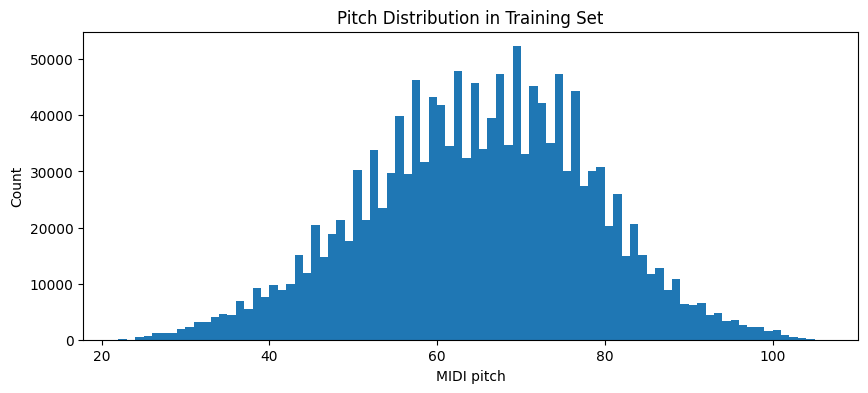

In [7]:
plt.figure(figsize=(10, 4))
plt.hist(
    all_pitches,
    bins=range(min(all_pitches), max(all_pitches) + 2)
)
plt.xlabel("MIDI pitch")
plt.ylabel("Count")
plt.title("Pitch Distribution in Training Set")
plt.show()

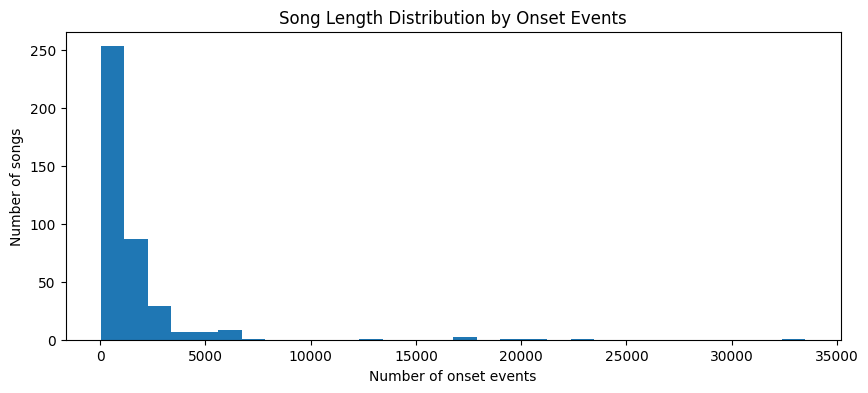

In [8]:
plt.figure(figsize=(10, 4))
plt.hist(song_event_lengths, bins=30)
plt.xlabel("Number of onset events")
plt.ylabel("Number of songs")
plt.title("Song Length Distribution by Onset Events")
plt.show()

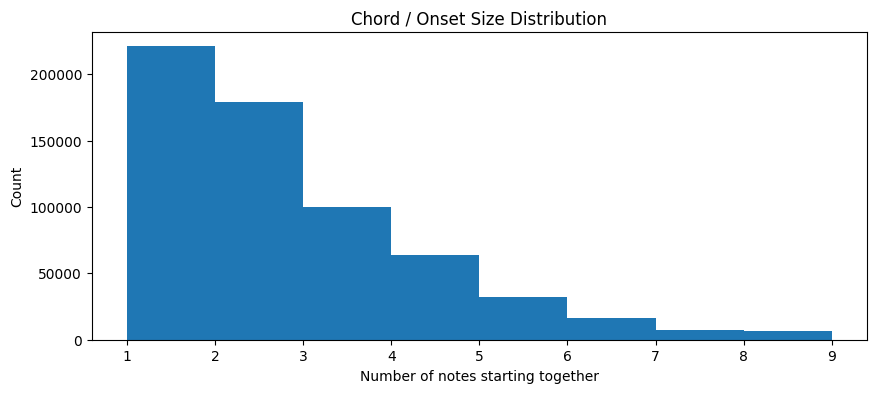

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(chord_sizes, bins=range(1, max(chord_sizes) + 2))
plt.xlabel("Number of notes starting together")
plt.ylabel("Count")
plt.title("Chord / Onset Size Distribution")
plt.show()

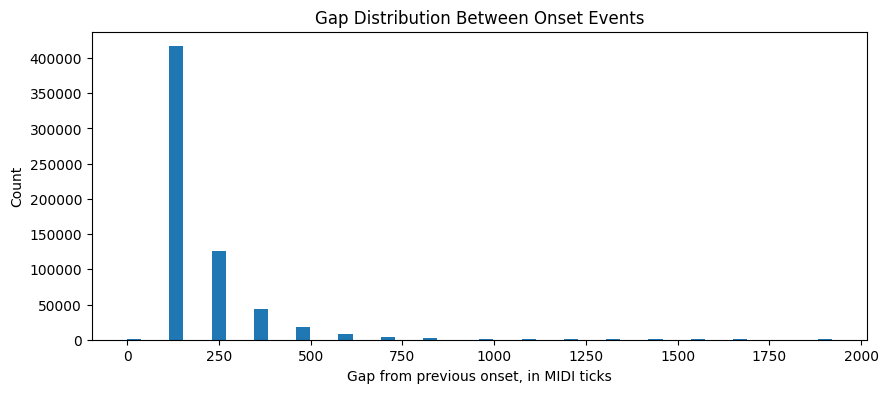

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(all_gaps, bins=50)
plt.xlabel("Gap from previous onset, in MIDI ticks")
plt.ylabel("Count")
plt.title("Gap Distribution Between Onset Events")
plt.show()

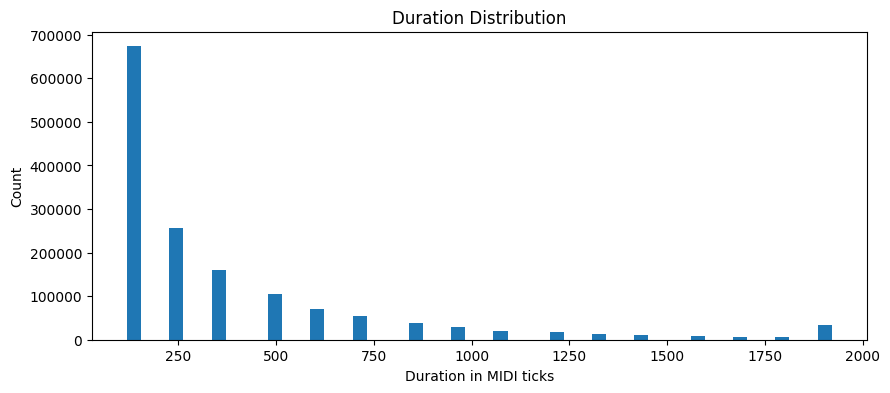

In [11]:
plt.figure(figsize=(10, 4))
plt.hist(all_durations, bins=50)
plt.xlabel("Duration in MIDI ticks")
plt.ylabel("Count")
plt.title("Duration Distribution")
plt.show()

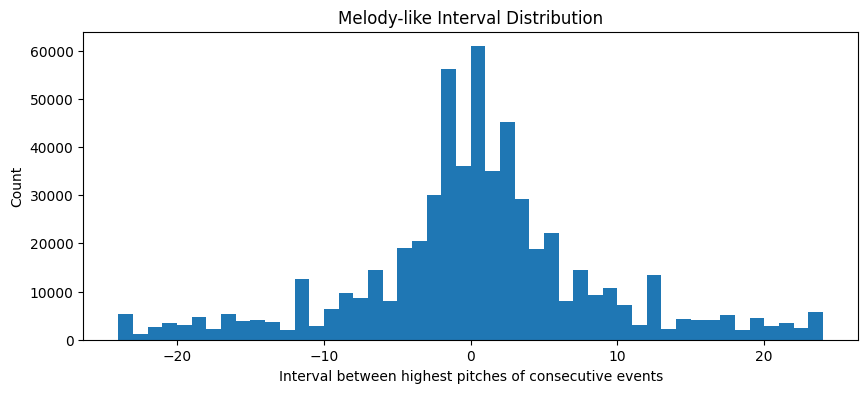

In [12]:
plt.figure(figsize=(10, 4))
plt.hist(event_intervals, bins=range(-24, 25))
plt.xlabel("Interval between highest pitches of consecutive events")
plt.ylabel("Count")
plt.title("Melody-like Interval Distribution")
plt.show()

##### ML STUFF!

This task is symbolic unconditioned generation. The model learns a distribution over onset events from the training MIDI files and samples new event sequences from that distribution.

I compare three models:

1. An event unigram baseline, which estimates p(event).
2. An event bigram Markov model, which estimates p(next event | previous event).
3. An event second-order Markov model, which estimates p(next event | previous two events).

Each event can contain multiple notes, so the model can generate chords and layered piano textures directly instead of relying on manual chord postprocessing.

In [13]:
event_unigram = train_event_unigram(train_songs)
event_bigram = train_event_bigram(train_songs)
event_second_order = train_event_second_order(train_songs)

model_summary = pd.DataFrame({
    "model_component": [
        "Event unigram model",
        "Event bigram model",
        "Event second-order model"
    ],
    "num_states": [
        len(event_unigram),
        len(event_bigram),
        len(event_second_order)
    ]
})

model_summary

,model_component,num_states
0,Event unigram model,251488
1,Event bigram model,251241
2,Event second-order model,535581


In [14]:
N_EVENTS = 300
TEMPERATURE = 0.8

unigram_events = generate_event_unigram(
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

bigram_events = generate_event_bigram(
    event_bigram,
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

second_order_events = generate_event_second_order(
    event_second_order,
    event_bigram,
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

print("Generated events:", len(second_order_events))
print("First 5 generated events:")

for event in second_order_events[:5]:
    print(event)

Generated events: 300
First 5 generated events:
{'gap': 120, 'pitches': (64,), 'durations': (480,)}
{'gap': 120, 'pitches': (67,), 'durations': (480,)}
{'gap': 120, 'pitches': (79, 82), 'durations': (360, 240)}
{'gap': 120, 'pitches': (85,), 'durations': (120,)}
{'gap': 120, 'pitches': (88,), 'durations': (240,)}


In [15]:
save_event_midi(
    unigram_events,
    OUTPUT_DIR / "event_unigram_sample.mid"
)

save_event_midi(
    bigram_events,
    OUTPUT_DIR / "event_bigram_sample.mid"
)

save_event_midi(
    second_order_events,
    OUTPUT_DIR / "symbolic_unconditioned.mid"
)

print("Saved generated MIDI files:")
print(OUTPUT_DIR / "event_unigram_sample.mid")
print(OUTPUT_DIR / "event_bigram_sample.mid")
print(OUTPUT_DIR / "markov.mid")

Saved generated MIDI files:
c:\CSE153-Assignment-2-Task-1\outputs\event_unigram_sample.mid
c:\CSE153-Assignment-2-Task-1\outputs\event_bigram_sample.mid
c:\CSE153-Assignment-2-Task-1\outputs\markov.mid


# Neural Models: LSTM vs. From-Scratch Transformer

The Markov models in the previous section counts the whole events of gap, pitches, and durations. The following two models, both of which are neural models, aim to learn the structure of the music instead of just memorizing it. 

## The problem: vocabulary explosion

The issue is, a full event has too much information to fit into a single token, which is why Markov is just memorization, and generates predictions based on those memorizations. Even the second-order Markov that is being used here requires a back-off mechanism, back to bigram or unigram. 

## The solution: event decomposition

Instead of one giant token per event, we decompose every event into a short, ordered sequence of sub-tokens: ```GAP_g  →  PITCH_p1  DUR_d1  →  PITCH_p2  DUR_d2  →  …  →  EOE ```

where `EOE` marks the end of an event. Because gaps and durations are quantised to a coarse grid in preprocessing and pitches live on the 88-key range, this collapses the vocabulary from ~250k atomic events down to just 125 sub-tokens, each one now seen tens of thousands of times. The network can share statistical strength across events. It learns that nearby pitches behave similarly and that certain gap/duration patterns recur, instead of treating every chord as an unrelated symbol.

## Roadmap for this section

1. **Tokeniser** - flatten the corpus into one ~4.3M sub-token stream.
2. **LSTM baseline** - a recurrent model to confirm the pipeline learns and to anchor the comparison.
3. **Transformer (main model)** - a from-scratch decoder-only network with a causal mask.
4. **Evaluation** - held-out per-event perplexity (objective) and musical statistics (subjective proxy).

In [ ]:
import torch
from neural import (
    EventTokenizer, EventLSTM, LSTMConfig, EventTransformer, TransformerConfig,
    train_model, generate, count_params,
)
from evaluation import (
    neural_event_perplexity, markov_event_perplexity,
    musical_report, reference_stats, pitch_class_histogram, kl_divergence,
    aggregate_reports,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

tokenizer = EventTokenizer()
print("Sub-token vocabulary size:", tokenizer.vocab_size)

train_stream = tokenizer.encode_songs(train_songs)
val_stream   = tokenizer.encode_songs(test_songs)
print("Train sub-tokens:", len(train_stream), "| Val sub-tokens:", len(val_stream))

Using device: cuda
Sub-token vocabulary size: 125
Train sub-tokens: 4256468 | Val sub-tokens: 903616


## The recurrent baseline: `EventLSTM`

We begin with a 2-layer LSTM. It does 3 things: confirming the tokeniser and training loop work end to end, giving the Transformer a fair recurrent competitor, and setting a reference perplexity to beat.

Architecturally, the LSTM compresses all preceding history into a fixed-size hidden state. That is cheap and fast, but it is also the model's limitation: long-range musical structure may not survive being squeezed through that bottleneck at every step. 

We expect this to cap how much global coherence it can hold onto, and the comparison below tests exactly that.

In [17]:
lstm = EventLSTM(LSTMConfig(
    vocab_size=tokenizer.vocab_size,
    embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.3,
))
print("LSTM parameters:", f"{count_params(lstm):,}")

lstm_history = train_model(
    lstm, train_stream, val_stream, tokenizer,
    block_size=256, epochs=20, batch_size=64, lr=3e-3,
    device=DEVICE, log_every=2,
)

LSTM parameters: 3,774,333
epoch   2 | train loss 1.7183 | val loss 1.5981 | val ppl/token 4.94
epoch   4 | train loss 1.5931 | val loss 1.5263 | val ppl/token 4.60
epoch   6 | train loss 1.5379 | val loss 1.4943 | val ppl/token 4.46
epoch   8 | train loss 1.5008 | val loss 1.4776 | val ppl/token 4.38
epoch  10 | train loss 1.4719 | val loss 1.4662 | val ppl/token 4.33
epoch  12 | train loss 1.4504 | val loss 1.4635 | val ppl/token 4.32
epoch  14 | train loss 1.4312 | val loss 1.4573 | val ppl/token 4.29
epoch  16 | train loss 1.4153 | val loss 1.4574 | val ppl/token 4.29
epoch  18 | train loss 1.4019 | val loss 1.4564 | val ppl/token 4.29
epoch  20 | train loss 1.3900 | val loss 1.4558 | val ppl/token 4.29
Restored best checkpoint from epoch 19 (val loss 1.4541, val ppl/token 4.28)


## The main model: decoder-only Transformer

Our primary model is a GPT-style decoder built from scratch: token embedding + learned positional encodings → a stack of pre-norm blocks (causal multi-head self-attention + MLP) → a final layer-norm → a weight-tied output head. The defining component is the causal self-attention mask: position t may attend to every position *≤ t* and never to the future, which is what makes the model a valid left-to-right generator.

In theory, since the Transformer has direct access to the whole context window (here 512 sub-tokens) rather than a compressed summary, it should capture longer-range dependencies. The configuration below is ~10.9M parameters. 

In [18]:
BLOCK_SIZE = 512

transformer = EventTransformer(TransformerConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=BLOCK_SIZE,
    n_layer=6, n_head=6, n_embd=384, dropout=0.1,
))
print("Transformer parameters:", f"{count_params(transformer):,}")

tf_history = train_model(
    transformer, train_stream, val_stream, tokenizer,
    block_size=BLOCK_SIZE, epochs=30, batch_size=32, lr=3e-4,
    device=DEVICE, log_every=2,
)

Transformer parameters: 10,892,160
epoch   2 | train loss 1.9287 | val loss 1.7622 | val ppl/token 5.83
epoch   4 | train loss 1.7173 | val loss 1.6070 | val ppl/token 4.99
epoch   6 | train loss 1.6154 | val loss 1.5332 | val ppl/token 4.63
epoch   8 | train loss 1.5531 | val loss 1.4873 | val ppl/token 4.43
epoch  10 | train loss 1.5037 | val loss 1.4556 | val ppl/token 4.29
epoch  12 | train loss 1.4610 | val loss 1.4325 | val ppl/token 4.19
epoch  14 | train loss 1.4214 | val loss 1.4211 | val ppl/token 4.14
epoch  16 | train loss 1.3854 | val loss 1.4120 | val ppl/token 4.10
epoch  18 | train loss 1.3505 | val loss 1.4102 | val ppl/token 4.10
epoch  20 | train loss 1.3167 | val loss 1.4146 | val ppl/token 4.11
epoch  22 | train loss 1.2838 | val loss 1.4171 | val ppl/token 4.13
epoch  24 | train loss 1.2519 | val loss 1.4330 | val ppl/token 4.19
epoch  26 | train loss 1.2208 | val loss 1.4464 | val ppl/token 4.25
epoch  28 | train loss 1.1914 | val loss 1.4658 | val ppl/token 4.33

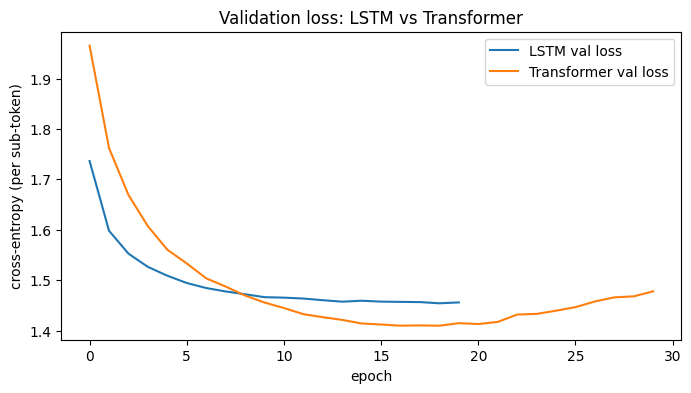

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(lstm_history["val_loss"], label="LSTM val loss")
plt.plot(tf_history["val_loss"],   label="Transformer val loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy (per sub-token)")
plt.title("Validation loss: LSTM vs Transformer")
plt.legend(); plt.show()

### Discussion: LSTM and Transformer are close!

The validation curve above is U-shaped for the Transformer. It bottoms out around epoch ~18–19 and then climbs as the model begins to memorise the training stream. The lower-capacity LSTM flattens out instead of turning up. This indicates the model is running short of data. Because of it, `train_model` keeps the best-validation checkpoint rather than the over-fit weights.



## Generation: autoregressive sampling

We generate one sub-token at a time, feed each choice back in as context, and finally decode the sub-token stream back into events. Two knobs shape the output:

- Temperature scales the logits: lower means more conservative and repetitive, while higher means more diverse and risky.
- Top-k / top-p (nucleus) truncation removes the long tail of implausible sub-tokens before sampling, trading diversity for coherence.

To keep the comparison fair we use identical decode settings for both neural models (so any difference reflects the model, not the sampler) and draw 5 samples per model, so the statistics below are reported as mean ± std rather than just luck.

In [ ]:
from midi_output import save_event_midi
from markov import generate_event_second_order
import random, numpy as np

# Identical decode settings for BOTH neural models so the comparison reflects
# the model and not the sampler. We also draw several samples per model so the
# musical statistics below are reported as mean +/- std rather than one lucky
# (or unlucky) draw, and we match sample lengths across model families.
N_SAMPLES = 5
DECODE = dict(temperature=0.95, top_p=0.95)
MAX_TOKENS = 2400
MARKOV_N = 250

def gen_neural(model):
    return [generate(model, tokenizer, max_tokens=MAX_TOKENS,
                     device=DEVICE, seed=s, **DECODE)
            for s in range(N_SAMPLES)]

def gen_markov():
    out = []
    for s in range(N_SAMPLES):
        random.seed(s); np.random.seed(s)
        out.append(generate_event_second_order(
            event_second_order, event_bigram, event_unigram,
            n=MARKOV_N, temperature=0.8))
    return out

tf_samples     = gen_neural(transformer)
lstm_samples   = gen_neural(lstm)
markov_samples = gen_markov()

tf_events, lstm_events, markov_events = tf_samples[0], lstm_samples[0], markov_samples[0]
save_event_midi(tf_events,     OUTPUT_DIR / "symbolic_unconditioned_transformer.mid")
save_event_midi(lstm_events,   OUTPUT_DIR / "lstm_sample.mid")
save_event_midi(markov_events, OUTPUT_DIR / "markov_sample.mid")

print("Saved symbolic_unconditioned.mid (transformer), lstm_sample.mid, markov_sample.mid")
print("events per transformer sample:", [len(s) for s in tf_samples])
print("events per lstm sample:       ", [len(s) for s in lstm_samples])
print("events per markov sample:     ", [len(s) for s in markov_samples])

Saved symbolic_unconditioned.mid (transformer), lstm_sample.mid, markov_sample.mid
events per transformer sample: [229, 314, 266, 294, 351]
events per lstm sample:        [222, 291, 413, 165, 274]
events per markov sample:      [250, 250, 250, 250, 250]


# Evaluation

How do we know whether generated music is "good"? We evaluate along two axes that, as it turns out, do not agree.

1. Objective: held-out per-event perplexity.** Because the neural models predict sub-tokens while the Markov models predict whole events, raw per-token perplexity is not comparable across families (finer tokenisation inflates token counts). We therefore score every model on the same unit: the negative log-likelihood of the next event given history (for the neural models, the summed log-probs of that event's sub-tokens). Lower is better.

2. Subjective proxy: musical statistics. Perplexity rewards predicting the data, not musical plausibility. So we also compare distributional properties of generated vs. real music: pitch-class distribution (KL divergence), polyphony, note density, repetition structure, and key consistency. A good model should match the real-data statistics, not just minimise perplexity.

TLDR: the neural models win on perplexity but lose on several musical statistics. The next two cells show this directly.

In [ ]:
import pandas as pd

lstm = lstm.to("cpu")
transformer = transformer.to("cpu")

def row(name, r):
    return {"model": name,
            "ppl_per_token": r["perplexity_per_token"],
            "nll_per_event_nats": r["nll_per_event"]}

rows = [
    row("Markov unigram",   markov_event_perplexity(test_songs, event_unigram, tokenizer=tokenizer)),
    row("Markov bigram",    markov_event_perplexity(test_songs, event_unigram, event_bigram, tokenizer=tokenizer)),
    row("Markov 2nd-order", markov_event_perplexity(test_songs, event_unigram, event_bigram, event_second_order, tokenizer=tokenizer)),
    row("LSTM",             neural_event_perplexity(lstm, tokenizer, test_songs, device="cpu")),
    row("Transformer",      neural_event_perplexity(transformer, tokenizer, test_songs, device="cpu")),
]
ppl_df = pd.DataFrame(rows).sort_values("ppl_per_token").reset_index(drop=True)
ppl_df

,model,ppl_per_token,nll_per_event_nats
0,Transformer,4.000007,9.611091
1,LSTM,4.139961,9.849517
2,Markov 2nd-order,4.489727,10.411815
3,Markov bigram,4.545164,10.496895
4,Markov unigram,4.896694,11.013375


So here, just based on perplexity, we see that the Transformer wins, then LSTM, then Markov, then the bigram and unigram, which are more baselines. On perplexity, the other 3 models win against the 2 baselines. 

In [ ]:
ref_events = [e for s in train_songs for e in s["events"]]

stats_rows = {
    "Real (train)": reference_stats(train_songs),
    "Markov 2nd":   aggregate_reports(markov_samples, ref_events),
    "LSTM":         aggregate_reports(lstm_samples,   ref_events),
    "Transformer":  aggregate_reports(tf_samples,     ref_events),
}
stats_df = pd.DataFrame(stats_rows).T
stats_df

,avg_polyphony,note_density,repetition_rate,distinct_event_ratio,key_consistency,pc_kl_vs_reference,num_events,num_notes,pitch_range
Real (train),2.392,1.4396,0.007,0.401,0.786,0.0,627312,1500523,"(22, 105)"
Markov 2nd,2.302 +/- 0.331,1.796 +/- 0.273,0.003 +/- 0.003,0.900 +/- 0.031,0.754 +/- 0.112,0.175 +/- 0.094,250,575,"(24, 104)"
LSTM,2.891 +/- 1.012,2.250 +/- 0.952,0.043 +/- 0.048,0.713 +/- 0.180,0.838 +/- 0.053,0.697 +/- 0.498,273,774,"(28, 99)"
Transformer,3.206 +/- 0.617,3.108 +/- 0.532,0.152 +/- 0.178,0.428 +/- 0.290,0.674 +/- 0.167,1.598 +/- 0.776,290,906,"(24, 99)"


### Discussion: perplexity is not musical plausibility

Very clearly, the Transformer seems to win on perplexity but then lose on basically all the other metrics, except the motif reuse. 

On held-out per-event perplexity the Transformer (~4.00) and LSTM (~4.14) beat the best Markov model (~4.49).

BUT, Markov model wins the pitch-class distribution. Its pitch-class histogram is far closer to real music: `pc_kl_vs_reference` ≈ 0.23 bits versus ≈ 0.59 (LSTM) and ≈ 1.71 (Transformer). Since the Markov model copies short verbatim n-grams from the corpus, it can reproduce the statistics from the real training data.

| Property | Best match to real | Comparison numbers |
|---|---|---|
| Held-out perplexity | Neural (Transformer) | (Transformer 4.00 vs Markov 4.49) |
| Pitch-class distribution (KL) | Markov | Markov 0.18 vs LSTM 0.70 vs Transformer 1.60, real = 0 |
| Texture (density / polyphony) | Markov | Markov polyphony & density runs closest to real |
| Key consistency (key clarity) | LSTM | LSTM 0.84 vs real 0.79; Markov 0.75; Transformer 0.67 |
| Motif reuse (distinct-event ratio) | Transformer | Transformer 0.43 vs real 0.40; LSTM 0.71; Markov 0.90 |

If you listen to the music produced, you can kind of see this play out. The Markov sounds most traditional and "classical" sounding, whereas Transformer and LSTM sound almost random and weird (from a very untrained amateur and ear like me).

The issue for the Transformer is that, you can see from the loss graph from above, it starts overfitting from such a small dataset. 

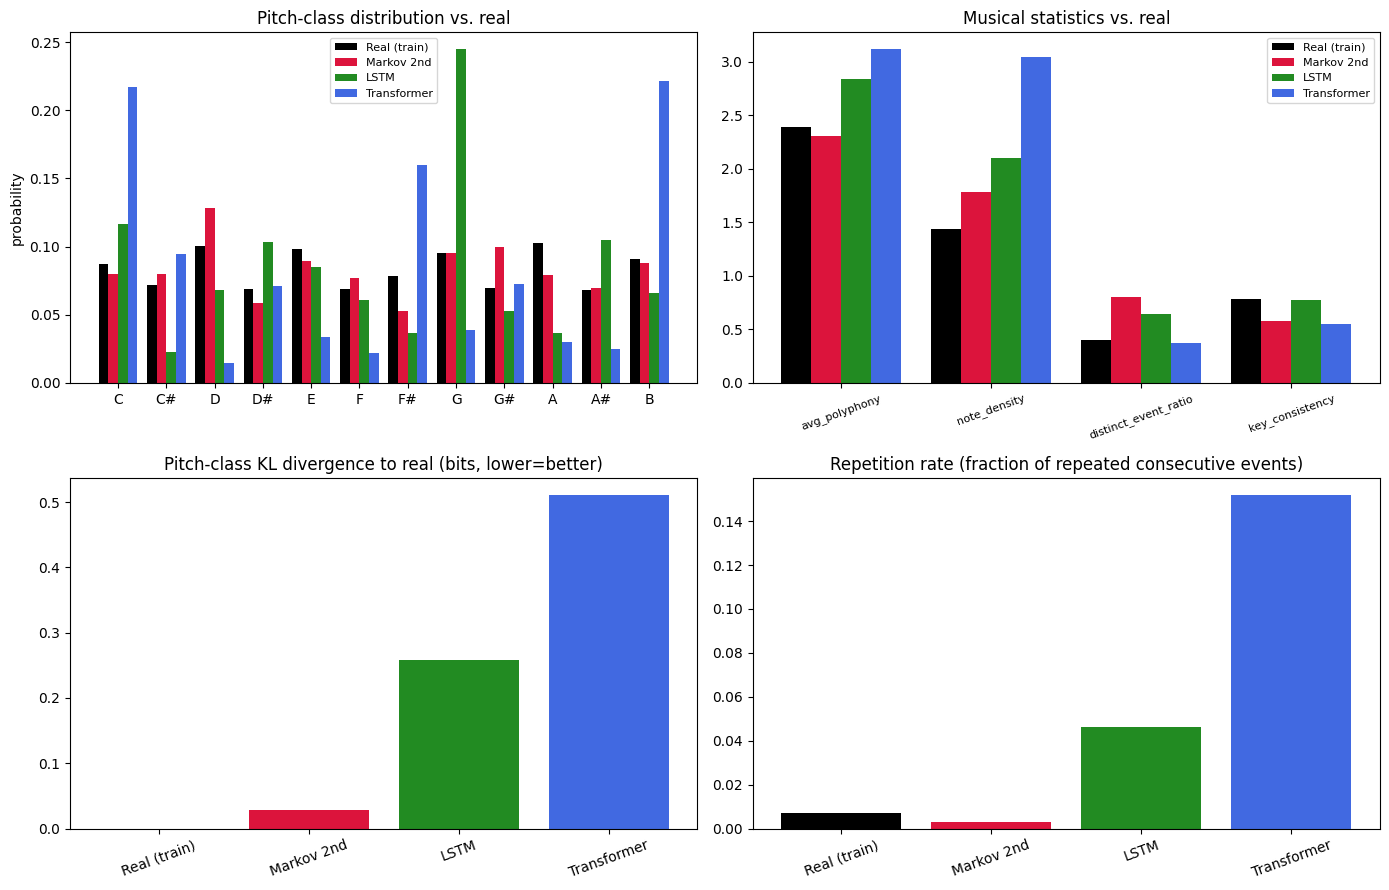

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from evaluation import (pitch_class_histogram, avg_polyphony, note_density,
                        distinct_event_ratio, repetition_rate, key_consistency)

def pool(samples):
    return [e for s in samples for e in s]

groups = {
    "Real (train)": ref_events,
    "Markov 2nd":   pool(markov_samples),
    "LSTM":         pool(lstm_samples),
    "Transformer":  pool(tf_samples),
}
colors = {"Real (train)": "black", "Markov 2nd": "crimson",
          "LSTM": "forestgreen", "Transformer": "royalblue"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

pc_names = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
x = np.arange(12); w = 0.2
for j, (name, ev) in enumerate(groups.items()):
    axes[0,0].bar(x + (j-1.5)*w, pitch_class_histogram(ev), width=w,
                  label=name, color=colors[name])
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(pc_names)
axes[0,0].set_title("Pitch-class distribution vs. real")
axes[0,0].set_ylabel("probability"); axes[0,0].legend(fontsize=8)

metrics = {
    "avg_polyphony": avg_polyphony,
    "note_density": note_density,
    "distinct_event_ratio": distinct_event_ratio,
    "key_consistency": key_consistency,
}
mnames = list(metrics)
xm = np.arange(len(mnames)); wm = 0.2
for j, (name, ev) in enumerate(groups.items()):
    vals = [metrics[m](ev) for m in mnames]
    axes[0,1].bar(xm + (j-1.5)*wm, vals, width=wm, label=name, color=colors[name])
axes[0,1].set_xticks(xm); axes[0,1].set_xticklabels(mnames, rotation=20, fontsize=8)
axes[0,1].set_title("Musical statistics vs. real"); axes[0,1].legend(fontsize=8)

kls = []
ref_pc = pitch_class_histogram(ref_events)
for name, ev in groups.items():
    p = pitch_class_histogram(ev) + 1e-8; q = ref_pc + 1e-8
    p /= p.sum(); q /= q.sum()
    kls.append(float(np.sum(p * np.log2(p / q))))
axes[1,0].bar(list(groups), kls, color=[colors[n] for n in groups])
axes[1,0].set_title("Pitch-class KL divergence to real (bits, lower=better)")
axes[1,0].tick_params(axis='x', rotation=20)

reps = [repetition_rate(ev) for ev in groups.values()]
axes[1,1].bar(list(groups), reps, color=[colors[n] for n in groups])
axes[1,1].set_title("Repetition rate (fraction of repeated consecutive events)")
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

## Pitch-class distribution: generated vs. real

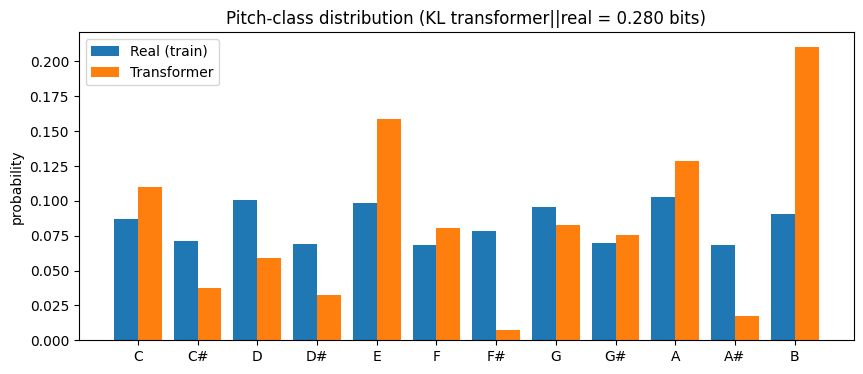

In [23]:
import numpy as np
import matplotlib.pyplot as plt

pc_names = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
ref_pc = pitch_class_histogram(ref_events)
tf_pc  = pitch_class_histogram(tf_events)

x = np.arange(12); w = 0.4
plt.figure(figsize=(10,4))
plt.bar(x - w/2, ref_pc, width=w, label="Real (train)")
plt.bar(x + w/2, tf_pc,  width=w, label="Transformer")
plt.xticks(x, pc_names); plt.ylabel("probability")
plt.title(f"Pitch-class distribution (KL transformer||real = "
          f"{kl_divergence(tf_pc, ref_pc):.3f} bits)")
plt.legend(); plt.show()

Let's look individually at pitch-class distribution of the Transformer vs. the Real data. The Real has a more uniform spread, which makes sense, because it's a combination of different songs as training, whereas the Transformer tends to use B,A, and E more, while absolutely hating A# and F#. It would almost be an E or A major key, if not for the fact that F# usage is low. In any case, it seems to have learned tonality, sticking to a set of favored notes rather than a spread of notes. 

## Conclusion: neural vs. statistical

Which is better depends on the situation. Both have their uses and for each scenario:

When you care about generalisation and long-range coherence, transformer is your tool, since it predicts unseen continuations (lowest perplexity) and reuses motifs the way real music does. 

For matching local distributional statistics (pitch-class profile, note density) on a small corpus, the second-order Markov chain is hard to beat and far cheaper to train. 

On this dataset the Transformer is only a slight improvement over Markov, since there isn't enough data to feed its capacity. For the Transformer to solidly "win", more (and augmented) training data is needed, at which point the long-range modelling the architecture is built for should separate it clearly from both the LSTM and the Markov baselines.

## Related works
Symbolic piano generation has moved through roughly the lineage our three models recapitulate. Statistical n-gram and Markov models are the classic count-based baseline, which we covered in our HWs.

Performance RNN (Oore et al.) introduced the event-based representation (a stream of timing, note-on, and duration tokens) and modeled it with an LSTM, which is essentially our EventLSTM. 

Music Transformer (Huang et al., 2018) then shows a self-attention decoder generates piano music with markedly better long-term structure than a recurrent model, because attention gives direct access to distant context rather than a compressed hidden state, which is what we were trying to hypothesize (theirs actually sounds good though LOL). Their key addition was relative positional attention, which we did not implement (we use learned absolute positions). They argue relative attention is what lets the model hold onto periodic timing and motif repetition over long spans. Beat-based tokenization schemes such as REMI (Huang & Yang, 2020) further refine how timing is encoded; our GAP/PITCH/DUR/EOE decomposition is a simpler member of the same event-token family.

Our finding that the Transformer edges the LSTM but does not decisively beat it runs against the large gap Music Transformer reports, but the difference is explained by scale. Their result comes from a much larger training corpus and relative attention. With only 399 songs, our Transformer overfits before you can really see the advantage. The direction of our result matches these previous related works (attention ≥ recurrence ≥ counting on held-out likelihood), though not with a decisive "win" that we wanted. 

Overall, a lot of these related works have been done at a larger scale. What we attempted was with a smaller subset of data, which demonstrates that the architecture can still work with smaller amounts of data, but not to its fullest effects. 


References
- Kong, Q., Li, B., Chen, J., & Wang, Y. (2020). GiantMIDI-Piano: A large-scale MIDI dataset for classical piano music. arXiv:2010.07061.
- Huang, C.-Z. A., Vaswani, A., Uszkoreit, J., Shazeer, N., Simon, I., Hawthorne, C., Dai, A. M., Hoffman, M. D., Dinculescu, M., & Eck, D. (2018). Music Transformer. arXiv:1809.04281 (ICLR 2019).
- Oore, S., Simon, I., Dieleman, S., Eck, D., & Simonyan, K. (2020). This Time with Feeling: Learning Expressive Musical Performance. Neural Computing and Applications, 32(4), 955–967. (arXiv:1808.03715, 2018.)
- Huang, Y.-S., & Yang, Y.-H. (2020). Pop Music Transformer: Beat-Based Modeling and Generation of Expressive Pop Piano Compositions. Proceedings of the 28th ACM International Conference on Multimedia (MM '20), 1180–1188.
